In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=False)

repository = scarf.cytebase.connect('scarf_docs')
remote_group = repository.open_zarr('tenx_5K_pbmc_rnaseq/data.zarr')

ds = scarf.DataStore(remote_group.store, zarr_mode='r', nthreads=4)

In [2]:
state = ds.get_assay_state('RNA')
print('Reduction available:', state.reduction is not None)
print('Graph available:', state.connectivity_map is not None)

Reduction available: True
Graph available: True


In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import zarr

source_uri = (
    "hf://buckets/Nygen/cytebase/scarf_docs/"
    "tenx_5K_pbmc_rnaseq/data.zarr"
)
mount_directory = TemporaryDirectory()
target_path = Path(mount_directory.name) / 'analysis.zarr'

In [4]:
mounted = scarf.mount_datastore(
    source_uri,
    at=str(target_path),
    storage_options={"token": False},
    nthreads=4,
)

In [5]:
target_root = zarr.open_group(str(target_path), mode='r')

print('Counts stored in target:', 'counts' in target_root['RNA'])
print('Mounted shape:', mounted.RNA.rawData.shape)

Counts stored in target: False
Mounted shape: (5025, 33538)


In [6]:
normalized = mounted.run_normalization(feat_key='hvgs')
pca = mounted.run_pca(normalized, dims=15, local_cache=True)
mounted.build_embedding_initialization(pca)
mounted.build_ann_index(pca)
mounted.query_neighbors(k=11)
mounted.build_connectivity_map()
mounted.run_umap(
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="mounted_UMAP",
)
mounted.run_leiden_clustering(
    resolution=0.5,
    label="mounted_clusters",
)

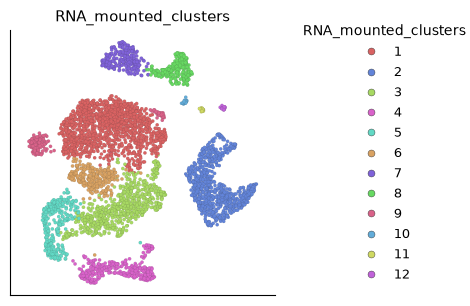

In [7]:
mounted.plots.embedding(
    layout_key="RNA_mounted_UMAP",
    color_by="RNA_mounted_clusters",
)

In [8]:
target_bytes = sum(
    path.stat().st_size
    for path in target_path.rglob("*")
    if path.is_file()
)
logical_count_bytes = int(
    np.prod(mounted.RNA.rawData.shape)
    * mounted.RNA.rawData.dtype.itemsize
)
print("Writable target bytes:", target_bytes)
print("Dense logical count bytes:", logical_count_bytes)

Writable target bytes: 8404246
Dense logical count bytes: 674113800


In [9]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
    storage_options={"token": False},
)
same_counts = np.array_equal(
    reopened.RNA.rawData[:20, :20].compute(),
    mounted.RNA.rawData[:20, :20].compute(),
)
print('Counts still resolve:', same_counts)
print('Normalization complete:', reopened.inspect_artifact(normalized).complete)

Counts still resolve: True
Normalization complete: True
